# Access 4DMED-SEA 3D Biophysical Fields
    * Original Data Source: https://4dmed.artov.ismar.cnr.it/thredds/catalog/4dmed/catalog_NN.html
    * Reference:  https://doi.org/10.25423/cmcc/4dmedsea_biophys_rep_3d
    * OSC entry: https://opensciencedata.esa.int/products/4dmed-t-s-geo-a-150/collection
    * License: CC-BY-4.0

In [ ]:
import xarray as xr 

zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/4dmed/4dmed-bp.zarr/'

In [10]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 3TB
Dimensions:  (time: 2405, lat: 378, lon: 1012, depth: 148)
Coordinates:
  * time     (time) datetime64[ns] 19kB 2016-01-01 2016-01-02 ... 2022-08-01
  * lat      (lat) float32 2kB 30.27 30.31 30.35 30.4 ... 45.85 45.9 45.94 45.98
  * lon      (lon) float32 4kB -6.062 -6.021 -5.979 -5.937 ... 35.98 36.02 36.06
  * depth    (depth) float32 592B -3.0 -4.0 -5.0 -6.0 ... -148.0 -149.0 -150.0
Data variables:
    CHL3D    (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 63, 92, 25), meta=np.ndarray>
    DS3D     (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 63, 92, 25), meta=np.ndarray>
    SAL3D    (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 63, 92, 25), meta=np.ndarray>
    TEMP3D   (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 63, 92, 25), meta=np.ndarray>
    UO3D     (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 63, 92, 25), meta=np.ndarray>
    VO3D     (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 63, 92, 25), meta=np.ndarray>
Attributes: (12/16)
    Conventions:            CF-1.7
    title:                  Neural network reconstruction of 3D Mediterranean...
    references:             Buongiorno Nardelli, B. A Deep Learning Network t...
    institution:            CNR
    project:                ESA 4DMED-Sea Project
    project_url:            http://ricerca.ismar.cnr.it/4DMED/index.html
    ...                     ...
    grid_resolution:        0.0416 degrees
    software_version:       4D MED Processor V1.0
    westernmost_longitude:  -6.062498
    easternmost_longitude:  36.0625
    southernmost_latitude:  30.270834
    northernmost_latitude:  45.979168

In [5]:
import numpy as np

day_index = 15 

surface_temp = (
    ds['TEMP3D']
    .isel(time=day_index)
    .sel(depth=1, method="nearest")
    .compute()
)

surface_temp

<xarray.DataArray 'TEMP3D' (lat: 378, lon: 1012)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(378, 1012), dtype=float32)
Coordinates:
  * lat      (lat) float32 2kB 30.27 30.31 30.35 30.4 ... 45.85 45.9 45.94 45.98
  * lon      (lon) float32 4kB -6.062 -6.021 -5.979 -5.937 ... 35.98 36.02 36.06
    depth    float32 4B -3.0
    time     datetime64[ns] 8B 2016-01-16
Attributes:
    units:          degrees_C
    long_name:      Neural network reconstruction of 3D Mediterranean tempera...
    standard_name:  sea_water_temperature

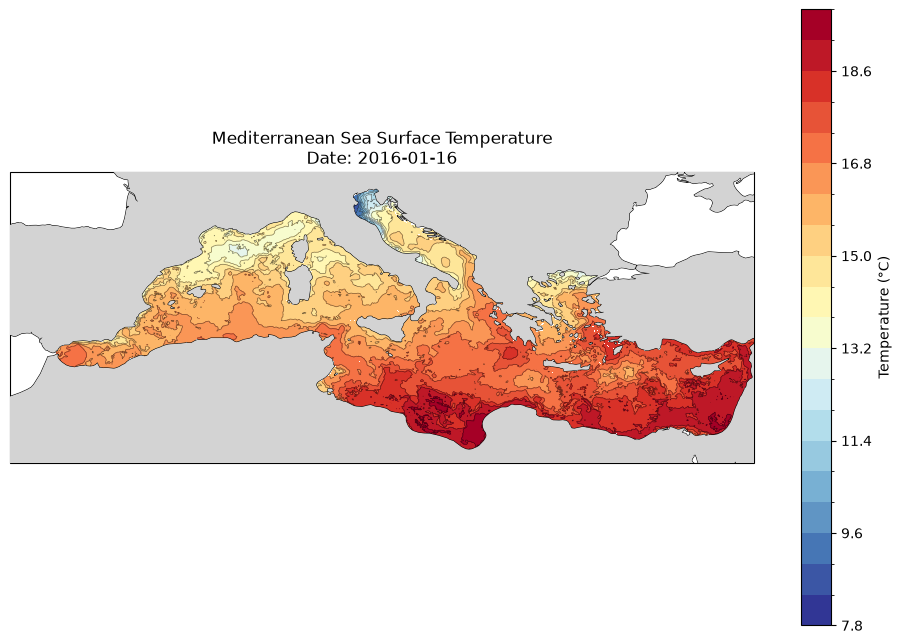

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 2. Set up the figure and the map projection
# PlateCarree is the standard equirectangular projection for lat/lon data
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add geographic features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=100) # Put land on top of ocean
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Set the map extent to the Mediterranean (approximate bounds)
# ax.set_extent([-6, 36, 30, 46], crs=ccrs.PlateCarree())

# 3. Plot filled contours (the colors)
# transform=ccrs.PlateCarree() tells Cartopy that your data coordinates are lat/lon
filled_c = surface_temp.plot.contourf(
    ax=ax,
    x='lon',
    y='lat',
    transform=ccrs.PlateCarree(),
    levels=20,               # Number of color gradients
    cmap='RdYlBu_r',         # Red-Yellow-Blue colormap (reversed so red=warm)
    cbar_kwargs={'label': 'Temperature (°C)'}
)

# 4. Plot contour lines on top
lines_c = surface_temp.plot.contour(
    ax=ax,
    x='lon',
    y='lat',
    transform=ccrs.PlateCarree(),
    levels=20,               # Keep levels identical to contourf to match boundaries
    colors='black',          # Black lines
    linewidths=0.5,
    alpha=0.5                # Slightly transparent
)

# Add a title dynamically using xarray attributes if they exist
time_str = str(surface_temp.time.values)[:10] # Gets 'YYYY-MM-DD'
ax.set_title(f"Mediterranean Sea Surface Temperature\nDate: {time_str}")

plt.show()